In [1]:
# now this is the process jiske through we can we can convert the given numerical data into the categorical data 

In [43]:
import pandas as pd
import numpy as np

In [40]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('titanic.csv', usecols = ['Age', 'Fare', 'Survived'])

In [5]:
# droped all missing values 

In [6]:
df.dropna(inplace = True)

In [7]:
df.shape

(714, 3)

In [8]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [9]:
kbin_age = KBinsDiscretizer(n_bins = 15, encode = 'ordinal', strategy = 'quantile', quantile_method='linear')

In [10]:
kbin_fare = KBinsDiscretizer(n_bins = 15, encode = 'ordinal', strategy = 'quantile', quantile_method='linear')

In [11]:
trf = ColumnTransformer([
    ('pehla',kbin_age,['Age']),
    ('dusra',kbin_fare,['Fare'])
])

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [15]:
x_train_transform = trf.fit_transform(x_train)

In [16]:
x_test_transform = trf.fit_transform(x_test)

In [17]:
trf.named_transformers_['pehla']

,n_bins,15
,encode,'ordinal'
,strategy,'quantile'
,quantile_method,'linear'
,dtype,None
,subsample,200000
,random_state,None


In [18]:
trf.named_transformers_['pehla'].bin_edges_

array([array([ 1.        ,  9.        , 15.9       , 17.        , 20.        ,
              21.        , 24.        , 26.        , 28.        , 30.1       ,
              33.66666667, 36.        , 38.6       , 44.06666667, 52.        ,
              62.        ])                                                   ],
      dtype=object)

In [19]:
trf.named_transformers_['dusra'].bin_edges_

array([array([  0.        ,   7.17166667,   7.77333333,   7.925     ,
                8.05      ,   9.5       ,  10.5       ,  13.        ,
               17.69333333,  22.62      ,  26.35276667,  31.275     ,
               38.1       ,  53.22666667,  79.27666667, 512.3292    ])],
      dtype=object)

In [20]:
output = pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_transform[:,0],
    'fare':x_train['Fare'],
    'fare_trf':x_train_transform[:,1]
})

In [21]:
output.head()

,age,age_trf,fare,fare_trf
328,31.0,8.0,20.5250,8.0
73,26.0,6.0,14.4542,7.0
253,30.0,8.0,16.1000,7.0
719,33.0,9.0,7.7750,2.0
666,25.0,6.0,13.0000,6.0


In [22]:
clf = DecisionTreeClassifier()
clf.fit(x_train_transform,y_train)
y_pred2 = clf.predict(x_test_transform)

In [23]:
accuracy_score(y_test,y_pred2)

0.6503496503496503

In [26]:
X_trf = trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

np.float64(0.6289514866979655)

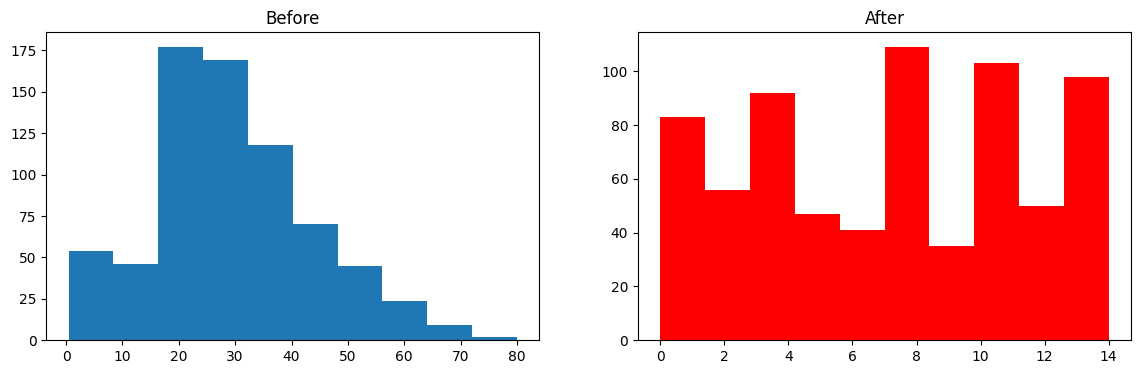

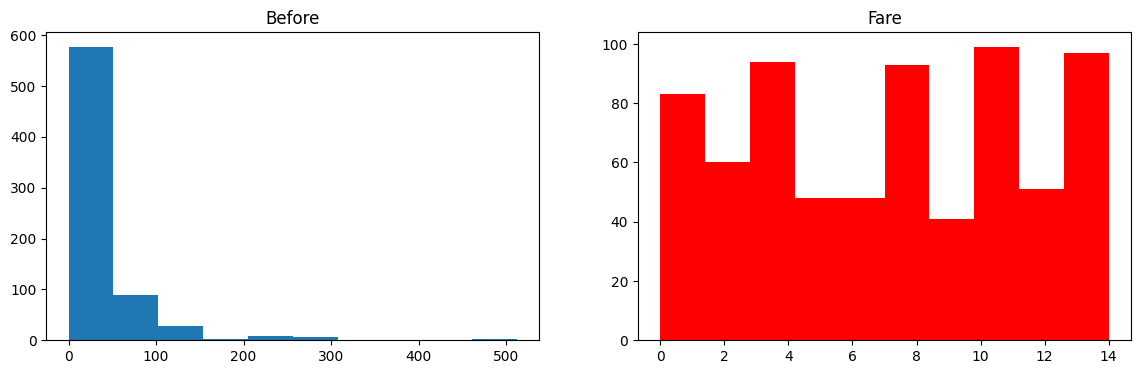

In [27]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(x['Age'])
plt.title("Before")

plt.subplot(122)
plt.hist(X_trf[:,0],color='red')
plt.title("After")

plt.show()
    
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(x['Fare'])
plt.title("Before")

plt.subplot(122)
plt.hist(X_trf[:,1],color='red')
plt.title("Fare")

plt.show()

In [28]:
kbin_age1 = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='uniform')
kbin_fare1 = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='uniform')

In [29]:
trf2 = ColumnTransformer([
    ('pehla',kbin_age1,['Age']),
    ('dusra',kbin_fare1,['Fare'])
])

In [30]:
X_trf = trf2.fit_transform(x)
print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))

0.6317097026604068


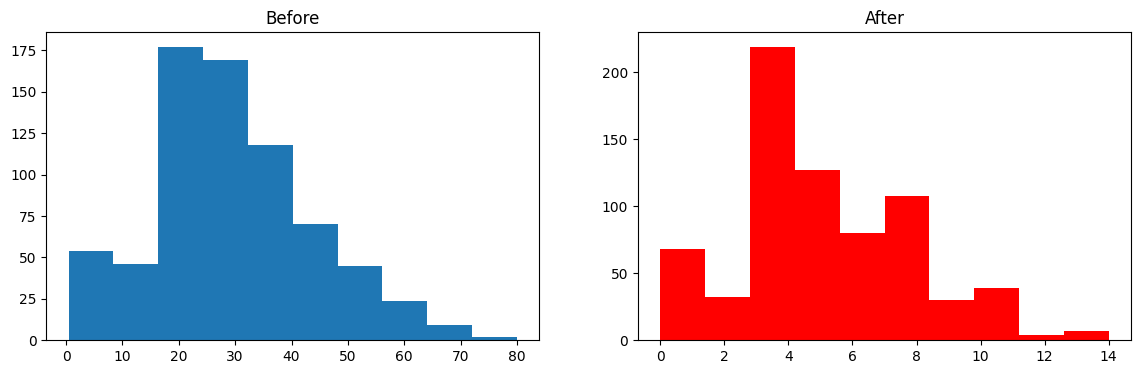

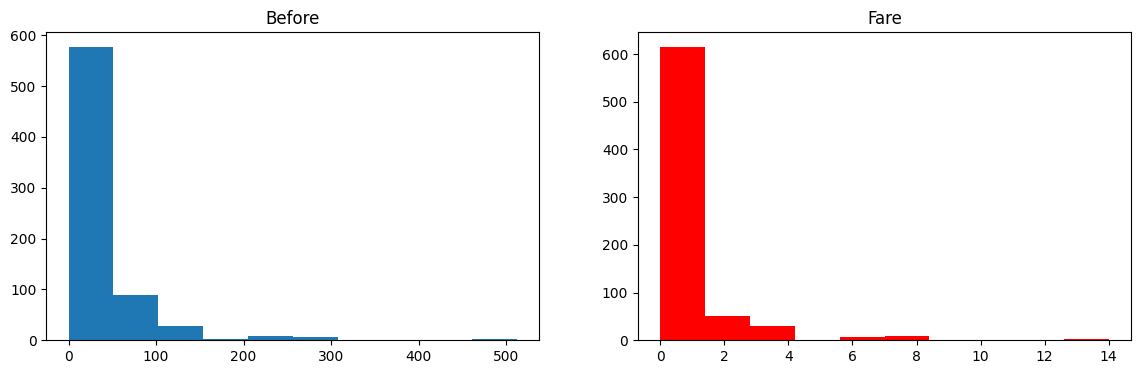

In [31]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(x['Age'])
plt.title("Before")

plt.subplot(122)
plt.hist(X_trf[:,0],color='red')
plt.title("After")

plt.show()
    
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(x['Fare'])
plt.title("Before")

plt.subplot(122)
plt.hist(X_trf[:,1],color='red')
plt.title("Fare")

plt.show()

In [50]:
kbin_age1 = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='kmeans')
kbin_fare1 = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='kmeans')

In [51]:
trf2 = ColumnTransformer([
    ('pehla',kbin_age1,['Age']),
    ('dusra',kbin_fare1,['Fare'])
])

In [52]:
X_trf = trf2.fit_transform(x)
print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))

0.6303012519561815


C:\Users\Tejas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Tejas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [53]:
import os
os.environ["OMP_NUM_THREADS"] = "3"

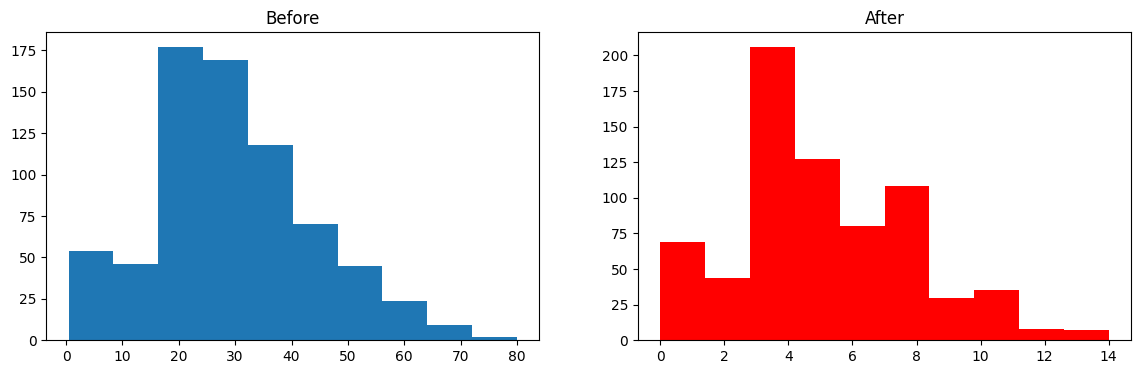

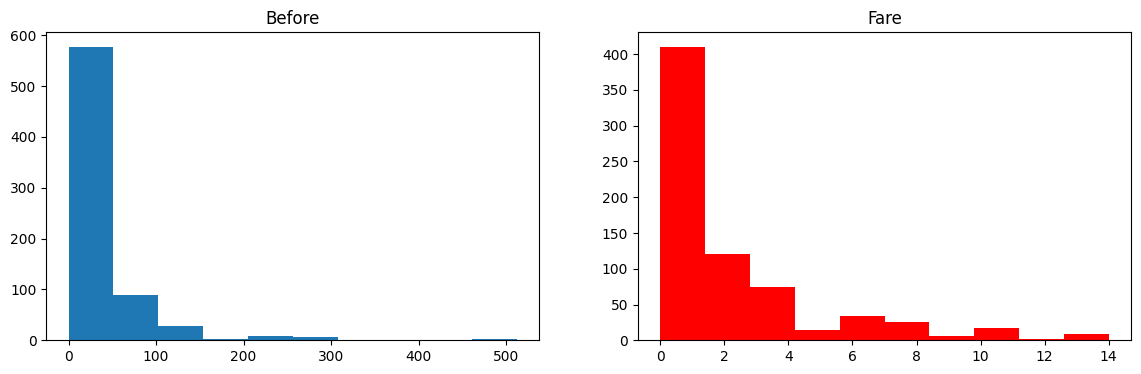

In [54]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(x['Age'])
plt.title("Before")

plt.subplot(122)
plt.hist(X_trf[:,0],color='red')
plt.title("After")

plt.show()
    
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(x['Fare'])
plt.title("Before")

plt.subplot(122)
plt.hist(X_trf[:,1],color='red')
plt.title("Fare")

plt.show()

In [58]:
kbin_age1 = KBinsDiscretizer(
    n_bins=5,
    encode='ordinal',
    strategy='kmeans'
)

kbin_fare1 = KBinsDiscretizer(
    n_bins=5,
    encode='ordinal',
    strategy='kmeans'
)

In [59]:
trf2 = ColumnTransformer([
    ('pehla', kbin_age1, ['Age']),
    ('dusra', kbin_fare1, ['Fare'])
])

X_trf = trf2.fit_transform(x)

C:\Users\Tejas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Tejas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


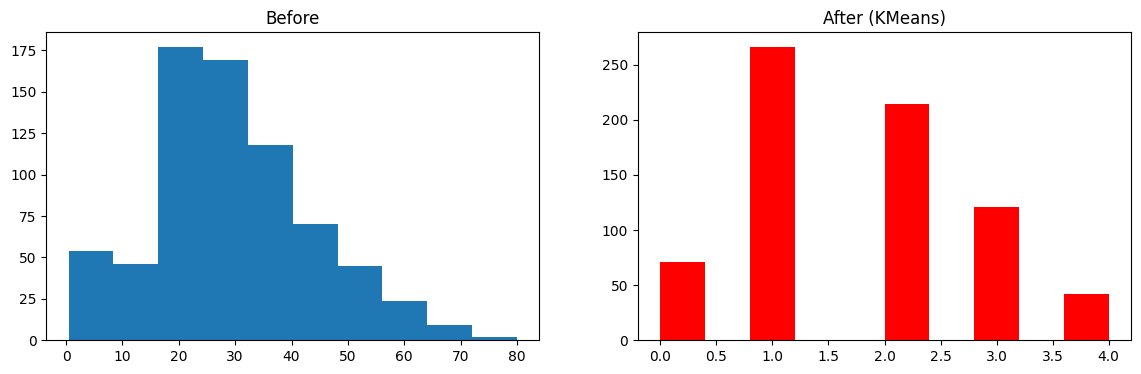

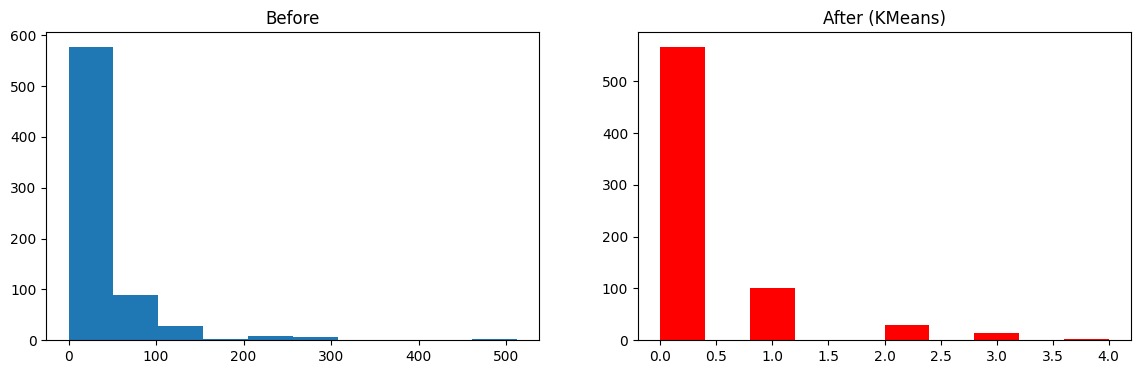

In [60]:
plt.figure(figsize=(14,4))

plt.subplot(121)
plt.hist(x['Age'])
plt.title("Before")

plt.subplot(122)
plt.hist(X_trf[:,0], color='red')
plt.title("After (KMeans)")

plt.show()


plt.figure(figsize=(14,4))

plt.subplot(121)
plt.hist(x['Fare'])
plt.title("Before")

plt.subplot(122)
plt.hist(X_trf[:,1], color='red')
plt.title("After (KMeans)")

plt.show()